# Nursery experiment layout TBR analysis

In [1]:
import math
import openmc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from openmc_model_vault import nursery_model

**Li2O packed bed properties**
Oxygen mass fraction: 0.5354685949864236 % mass
Lithium mass fraction: 0.46451900615072256 % mass
Helium mass fraction: 1.2398862853919525e-05 % mass
Pellet bed density: 1.3386615978815597 g/cm3


### Geometry

In [2]:
model = nursery_model()
geometry = model.geometry

Building BABY 1 geometry...
Building BABY 2 geometry...
Building BABY 3 geometry...
isotopes ['Ag107', 'Ag109', 'Al27', 'Ar36', 'Ar38', 'Ar40', 'As75', 'B10', 'B11', 'Be9', 'Bi209', 'C12', 'C13', 'Ca40', 'Ca42', 'Ca43', 'Ca44', 'Ca46', 'Ca48', 'Cd106', 'Cd108', 'Cd110', 'Cd111', 'Cd112', 'Cd113', 'Cd114', 'Cd116', 'Cl35', 'Cl37', 'Co59', 'Cr50', 'Cr52', 'Cr53', 'Cr54', 'Cu63', 'Cu65', 'F19', 'Fe54', 'Fe56', 'Fe57', 'Fe58', 'H1', 'H2', 'He3', 'He4', 'K39', 'K40', 'K41', 'Li6', 'Li7', 'Mg24', 'Mg25', 'Mg26', 'Mn55', 'Mo100', 'Mo92', 'Mo94', 'Mo95', 'Mo96', 'Mo97', 'Mo98', 'N14', 'N15', 'Na23', 'Nb93', 'Ni58', 'Ni60', 'Ni61', 'Ni62', 'Ni64', 'O16', 'O17', 'O18', 'P31', 'Pb204', 'Pb206', 'Pb207', 'Pb208', 'S32', 'S33', 'S34', 'S36', 'Sb121', 'Sb123', 'Si28', 'Si29', 'Si30', 'Sn112', 'Sn114', 'Sn115', 'Sn116', 'Sn117', 'Sn118', 'Sn119', 'Sn120', 'Sn122', 'Sn124', 'Ti46', 'Ti47', 'Ti48', 'Ti49', 'Ti50', 'Tl203', 'Tl205', 'W182', 'W183', 'W184', 'W186', 'Zn64', 'Zn66', 'Zn67', 'Zn68', 'Zn70',

### Vault Geometry

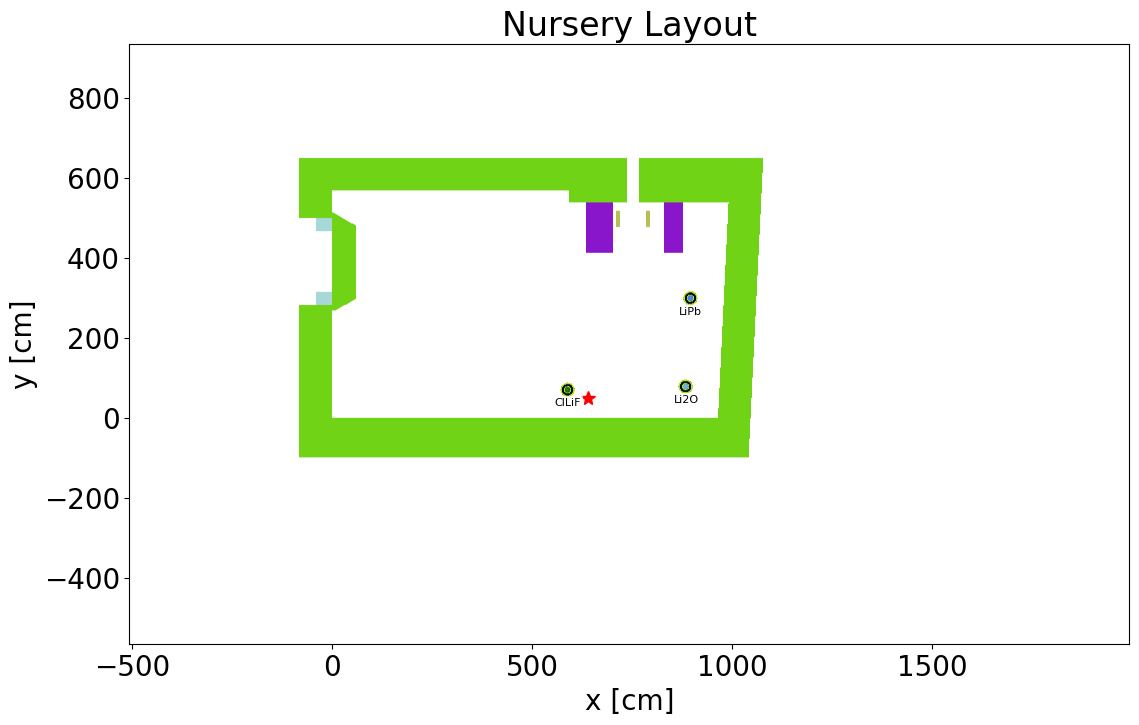

In [3]:
# Visualization

from libra_toolbox.neutronics.vault import Air
from openmc_model_vault import air, baby_positions, breeders

# Calculate midpoint position (center of bounding box)
min_xyz = np.min(baby_positions, axis=0)
max_xyz = np.max(baby_positions, axis=0)
midpoint = (min_xyz + max_xyz) / 2
x_c, y_c, z_c = midpoint

# Get the source BABY position
source_idx = nursery_model.source_position - 1 if hasattr(nursery_model, "source_position") else 0
source_x, source_y, source_z = baby_positions[source_idx]


ax = geometry.plot(
    width=(2500, 1500),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)

# Add a red star marker for the neutron source
ax.plot(source_x + 50, source_y -22, marker='*', color='red', markersize=10, label='Neutron Source')

# Add breeder material labels under each BABY
for (bx, by, bz), breeder in zip(baby_positions, breeders):
    ax.text(
        bx, by - 20,  # Adjust -20 as needed for spacing
        breeder,
        color='black',
        fontsize=8,
        ha='center',
        va='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )

ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout", fontsize=24)
plt.show()

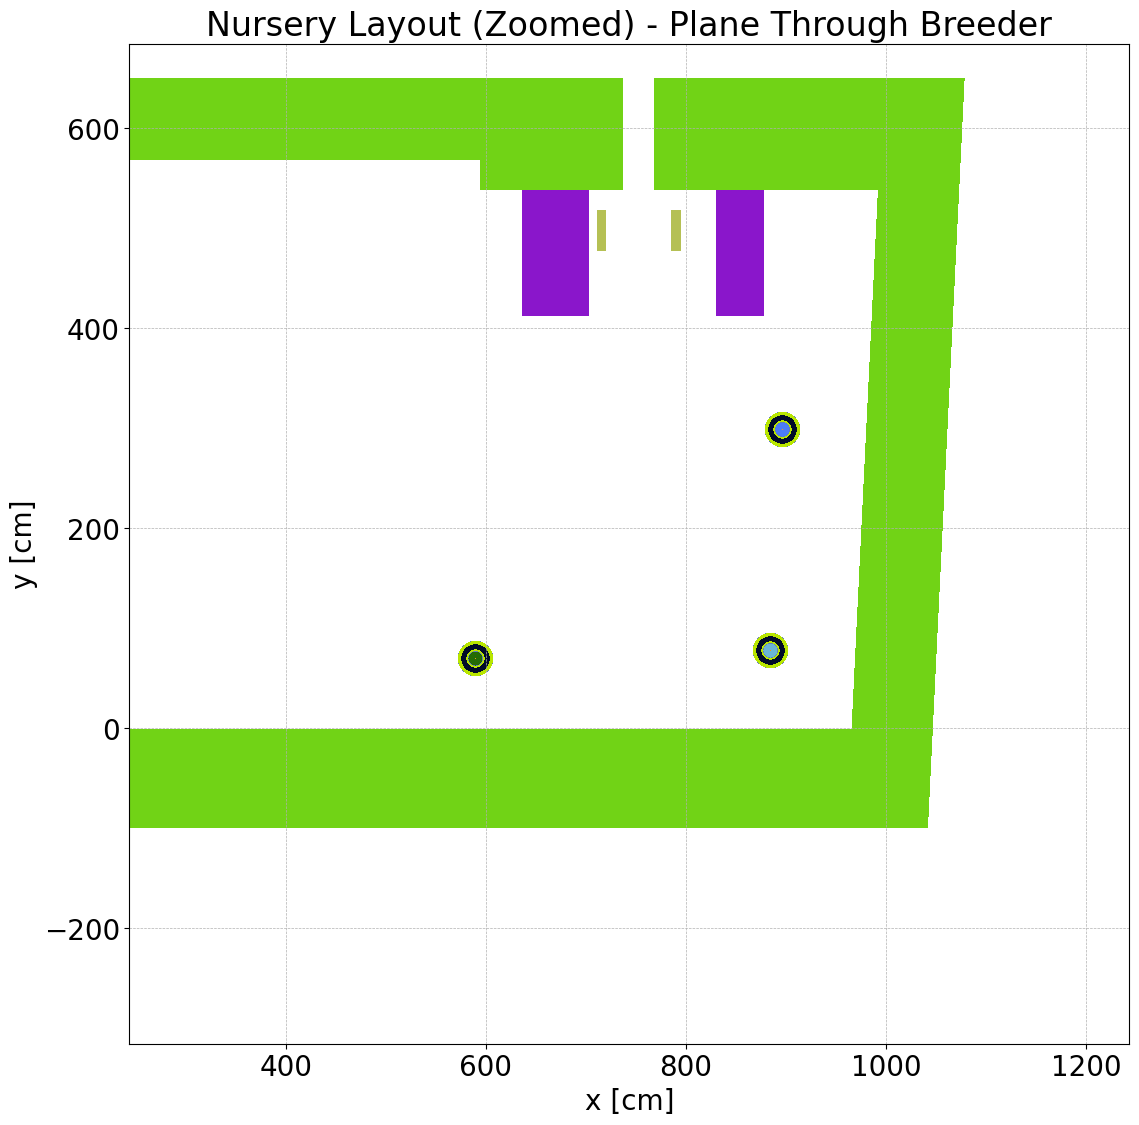

In [4]:
ax = geometry.plot(
    width=(1000, 1000),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout (Zoomed) - Plane Through Breeder", fontsize=24)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

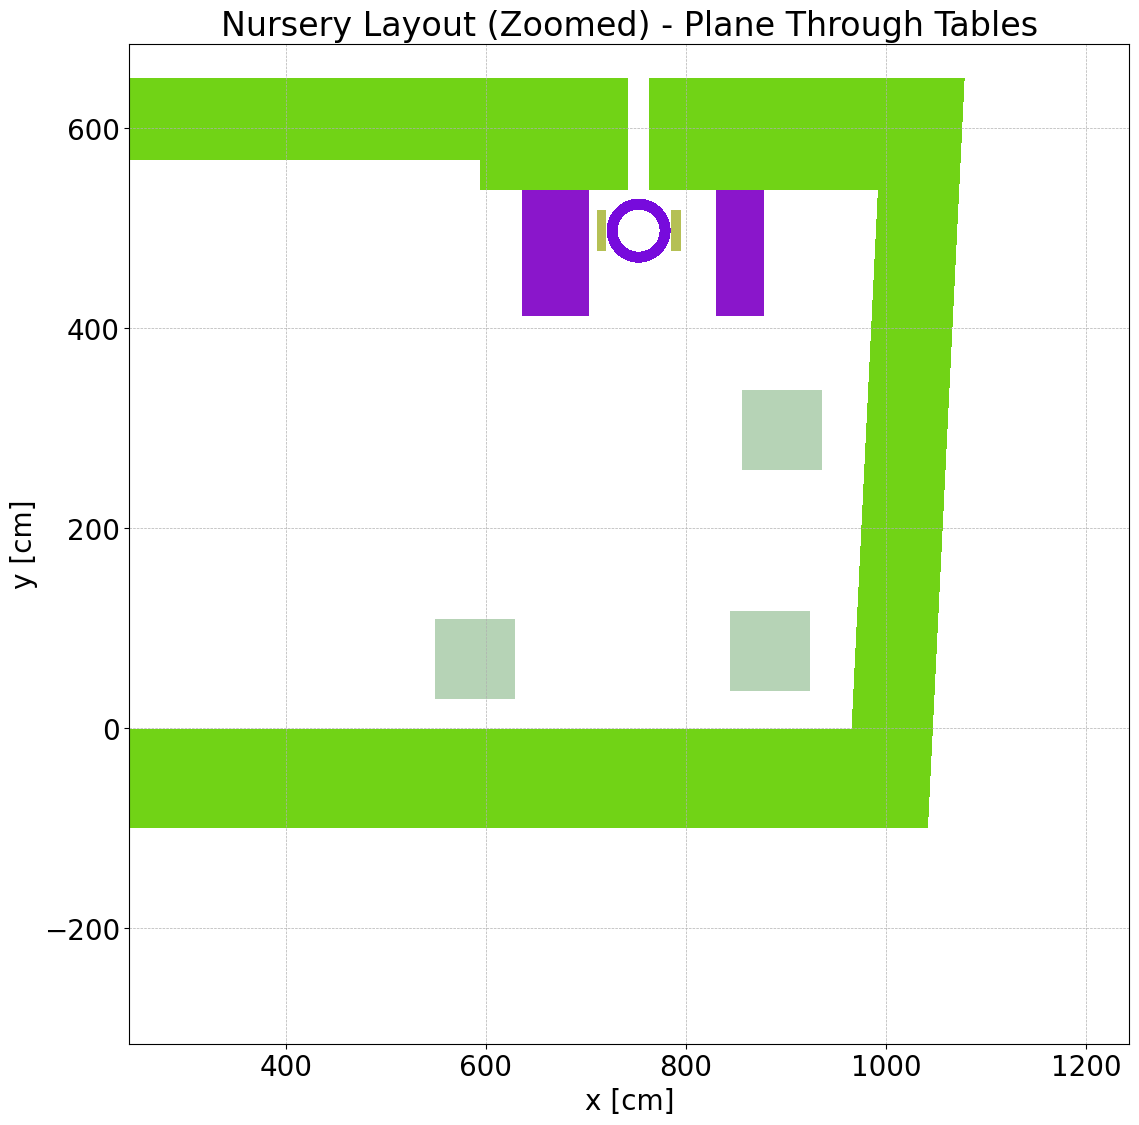

In [5]:
ax = geometry.plot(
    width=(1000, 1000),
    origin=(x_c, y_c, z_c + 1),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout (Zoomed) - Plane Through Tables", fontsize=24)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

### BABYs YZ View

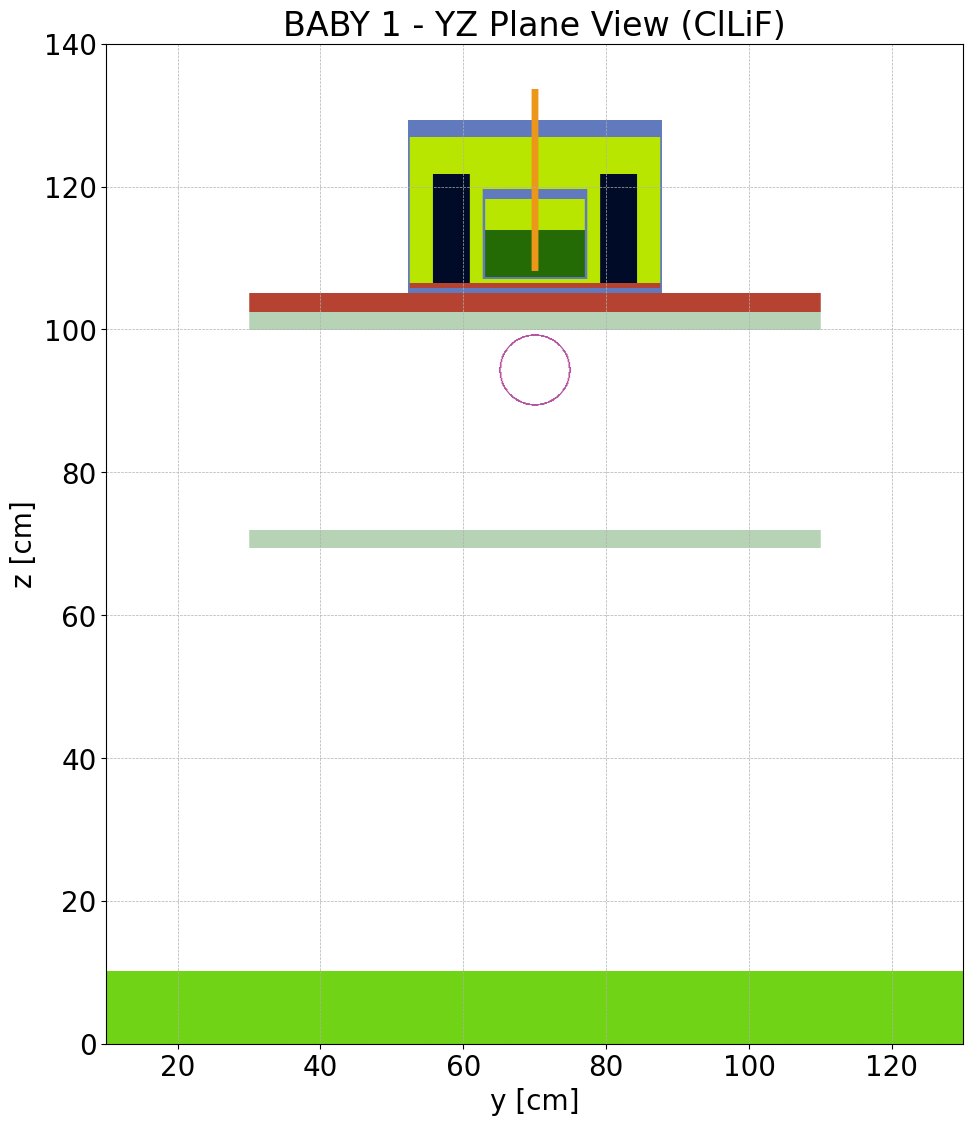

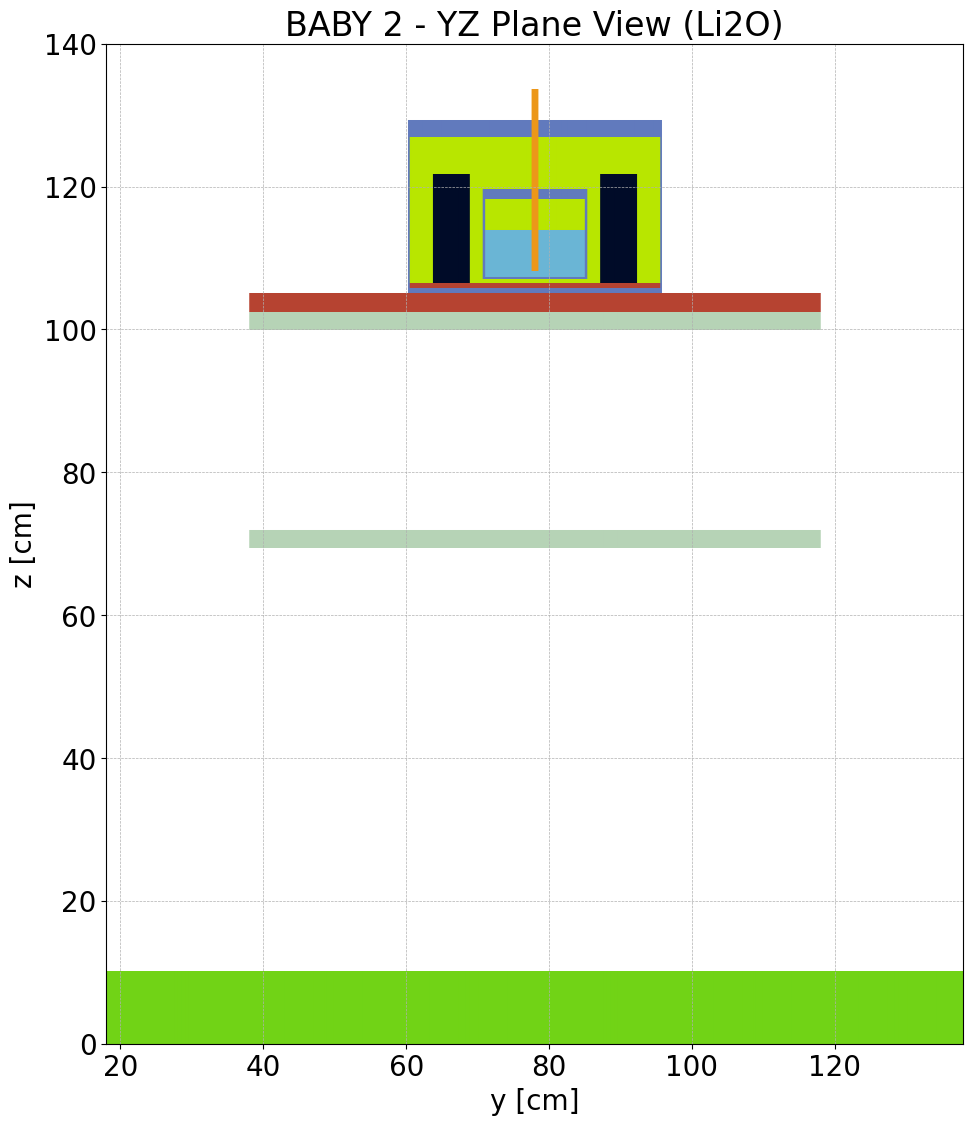

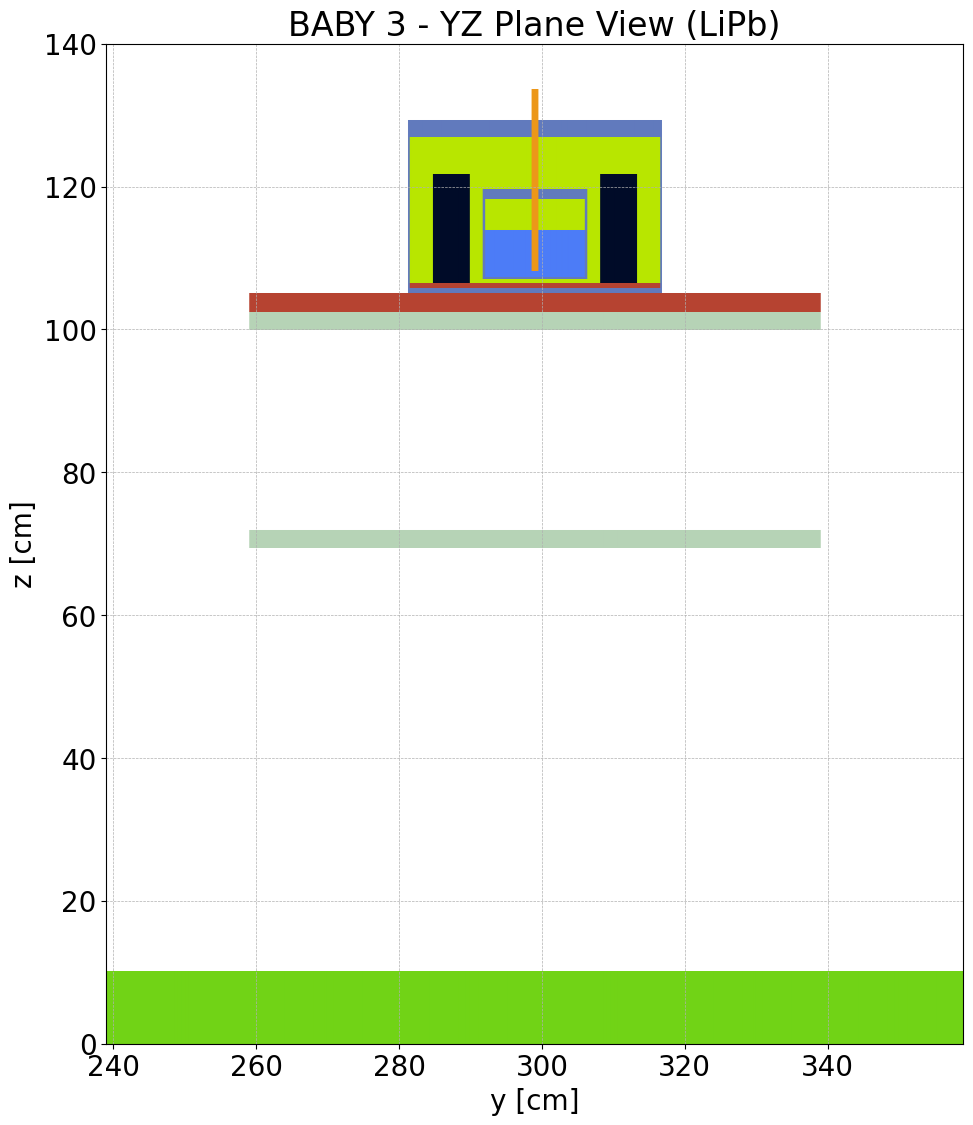

In [6]:
for i, (x_c, y_c, z_c) in enumerate(baby_positions):
    ax = geometry.plot(
        width=(120, (z_c + 40)),
        origin=(x_c, y_c, (z_c + 40)/2),
        pixels=(1000, 1000),
        basis="yz",
        color_by="material",
        colors={Air: "white", air: "white"},
    )
    ax.tick_params(axis="both", labelsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=20)
    ax.set_ylabel(ax.get_ylabel(), fontsize=20)
    ax.set_title(f"BABY {i+1} - YZ Plane View ({breeders[i]})", fontsize=24)
    plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
    plt.show()

### TBR Results

Nursery model simulation completed successfully.
BABY locations and breeder materials:
  BABY 1 at position (590, 70, 100) cm with breeder material: ClLiF
  BABY 2 at position (885, 78, 100) cm with breeder material: Li2O
  BABY 3 at position (897, 299, 100) cm with breeder material: LiPb
BABY 1 TBR: 1.511001e-03
BABY 1 TBR std. dev: 2.907341e-05
BABY 1 Relative standard deviation: 1.924115e-02

BABY 2 TBR: 1.082697e-04
BABY 2 TBR std. dev: 1.216843e-05
BABY 2 Relative standard deviation: 1.123900e-01

BABY 3 TBR: 5.005301e-05
BABY 3 TBR std. dev: 8.779389e-06
BABY 3 Relative standard deviation: 1.754018e-01

Relative standard deviation below 1e-02 (1%) indicates good convergence.


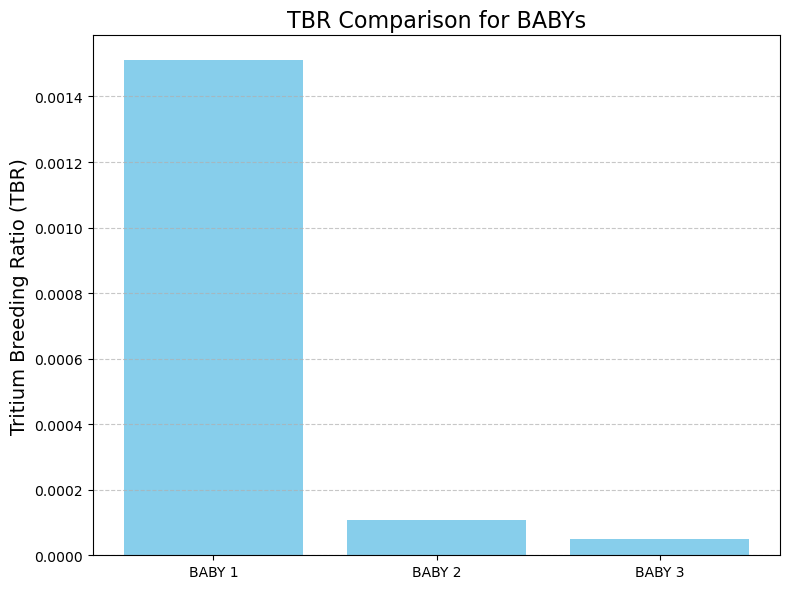

In [7]:
# Load the statepoint file
sp = openmc.StatePoint(f"statepoint.{model.settings.batches}.h5")

print("Nursery model simulation completed successfully.")
print("BABY locations and breeder materials:")
for i, (pos, breeder) in enumerate(zip(baby_positions, breeders), start=1):
    print(f"  BABY {i} at position {pos} cm with breeder material: {breeder}")

# Dynamically process TBR results for all BABYs
tbr_means = []
tbr_stdevs = []

for i in range(len(baby_positions)):
    tally_name = f"TBR_{i+1}"
    tbr_tally = sp.get_tally(name=tally_name).get_pandas_dataframe()
    mean = tbr_tally["mean"].iloc[0]
    stdev = tbr_tally["std. dev."].iloc[0]
    rel_stdev = stdev / mean

    tbr_means.append(mean)
    tbr_stdevs.append(stdev)

    print(f"BABY {i+1} TBR: {mean:.6e}")
    print(f"BABY {i+1} TBR std. dev: {stdev:.6e}")
    print(f"BABY {i+1} Relative standard deviation: {rel_stdev:.6e}\n")

print("Relative standard deviation below 1e-02 (1%) indicates good convergence.")

# Bar chart comparison of TBR results
labels = [f"BABY {i+1}" for i in range(len(baby_positions))]
plt.figure(figsize=(8, 6))
plt.bar(labels, tbr_means, capsize=8, color='skyblue')
plt.ylabel("Tritium Breeding Ratio (TBR)", fontsize=14)
plt.title("TBR Comparison for BABYs", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()